In [ ]:
pip install kagglehub pandas matplotlib seaborn

In [1]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

# Copio el archivo descargado a la carpeta dataset
dest = os.path.join(os.getcwd(), "dataset")
os.makedirs(dest, exist_ok=True)
for f in os.listdir(path):
    shutil.copy2(os.path.join(path, f), os.path.join(dest, f))

print("Path al dataset:", dest)

f:\Facu-temp\Mg-Datos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 734k/734k [00:00<00:00, 955kB/s]

Extracting files...
Path al dataset: f:\Facu-temp\Mg-Datos\automatizacion-test\dataset


In [15]:
from pathlib import Path
import pandas as pd
diabetes = pd.read_csv("dataset/diabetes_prediction_dataset.csv")

## Análisis Exploratorio de Datos (EDA)

In [16]:
diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [17]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [6]:
diabetes.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## Calidad de datos

Vemos si hay nulos

In [13]:
nulos=diabetes.isnull().sum()
nulos_pct = nulos / len(diabetes) * 100
nulos_df = pd.DataFrame({"nulos": nulos, "nulos_pct": nulos_pct})
print('Datos nulos por columna:')
print(nulos_df[nulos_df["nulos"] > 0])
if nulos_df["nulos"].sum() == 0:
    print("No hay datos nulos en el dataset.")

Datos nulos por columna:
Empty DataFrame
Columns: [nulos, nulos_pct]
Index: []
No hay datos nulos en el dataset.


Vemos si hay registros duplicados

In [18]:
duplicados = diabetes.duplicated().sum()
print(f"Datos duplicados: {duplicados} ({duplicados / len(diabetes) * 100:.2f}%)")

Datos duplicados: 3854 (3.85%)


Hay, los quitamos, pueden traer inconvenientes si caen el mismo conjunto de split

In [19]:
diabetes.drop_duplicates(inplace=True, ignore_index=True)
diabetes.shape

(96146, 9)

Volvemos a describir

In [28]:
diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
age,96146.0,41.794326,22.462948,0.08,24.0,43.00,59.00,80.00
hypertension,96146.0,0.077601,0.267544,0.00,0.0,0.00,0.00,1.00
heart_disease,96146.0,0.040803,0.197833,0.00,0.0,0.00,0.00,1.00
bmi,96146.0,27.321461,6.767716,10.01,23.4,27.32,29.86,95.69
HbA1c_level,96146.0,5.532609,1.073232,3.50,4.8,5.80,6.20,9.00
blood_glucose_level,96146.0,138.218231,40.909771,80.00,100.0,140.00,159.00,300.00
diabetes,96146.0,0.088220,0.283616,0.00,0.0,0.00,0.00,1.00


Valores únicos por columna

In [27]:
for col in diabetes.columns:
    print(f"Columna {col}: {diabetes[col].nunique()} valores únicos")
    if diabetes[col].nunique() < 10:
        print(f"Valores: {diabetes[col].unique()}")

Columna gender: 3 valores únicos
Valores: <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
Columna age: 102 valores únicos
Columna hypertension: 2 valores únicos
Valores: [0 1]
Columna heart_disease: 2 valores únicos
Valores: [1 0]
Columna smoking_history: 6 valores únicos
Valores: <StringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str
Columna bmi: 4247 valores únicos
Columna HbA1c_level: 18 valores únicos
Columna blood_glucose_level: 18 valores únicos
Columna diabetes: 2 valores únicos
Valores: [0 1]


In [36]:
print(diabetes["smoking_history"].value_counts())
print(f"'No Info' en smoking_history: {(diabetes['smoking_history'] == 'No Info').sum()} ({(diabetes['smoking_history'] == 'No Info').mean() * 100:.2f}%)")

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64
'No Info' en smoking_history: 32887 (34.21%)


Investigamos también Género

In [37]:
diabetes['gender'].value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Gráficos univariables

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

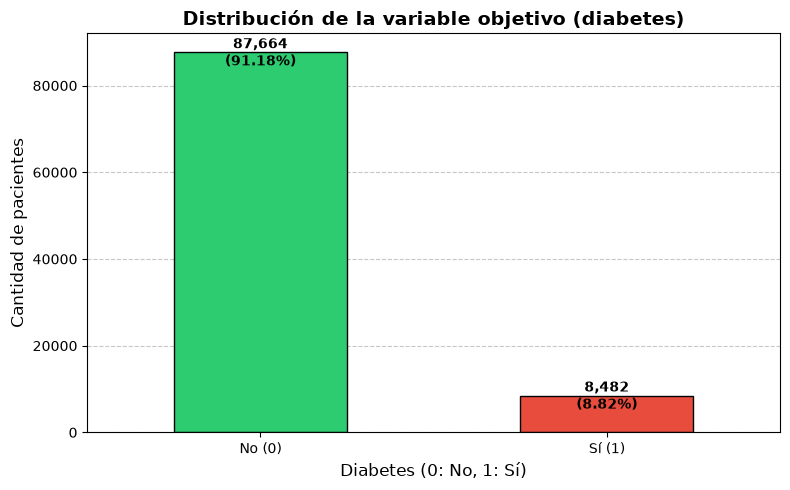

In [57]:
# Visualización de la distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(8, 5))
color = ['#2ecc71', '#e74c3c']
diabetes['diabetes'].value_counts().plot(kind='bar', color=color, edgecolor='black', ax=ax)
ax.set_title('Distribución de la variable objetivo (diabetes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Diabetes (0: No, 1: Sí)', fontsize=12)
ax.set_ylabel('Cantidad de pacientes', fontsize=12)
ax.set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)

for i, v in enumerate(diabetes['diabetes'].value_counts()):
    ax.text(i, v -3000, f'{v:,}\n({v/len(diabetes)*100:.2f}%)', color='black', ha='center', fontweight='bold')
    
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

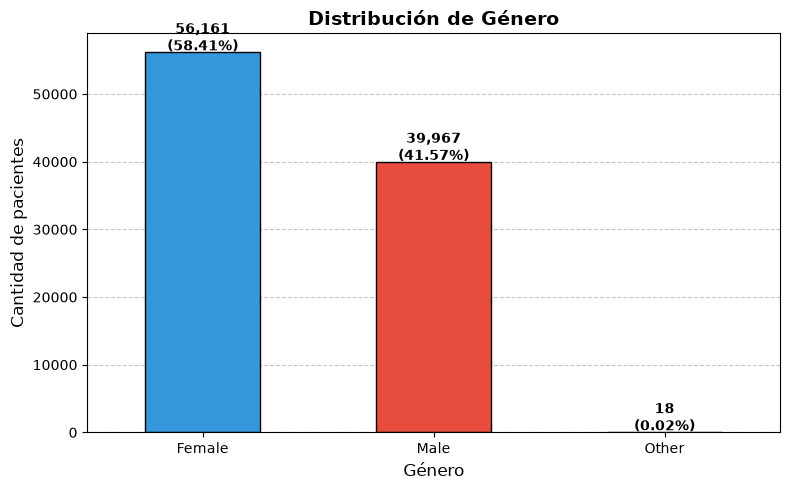

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))
color =['#3498db', '#e74c3c', '#95a5a6']
diabetes['gender'].value_counts().plot(kind='bar', color=color, edgecolor='black', ax=ax)
ax.set_title('Distribución de Género', fontsize=14, fontweight='bold')
ax.set_xlabel('Género', fontsize=12)
ax.set_ylabel('Cantidad de pacientes', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(diabetes['gender'].value_counts()):
    ax.text(i, v + 300, f'{v:,}\n({v/len(diabetes)*100:.2f}%)', color='black', ha='center', fontweight='bold')
    
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Género:** muestra levemente desbalanceada: 58.41% mujeres, 41.57% varones y apenas 18 registros (0.02%) en la categoría *Other*. Más adelante tomaremos una decisión sobre la categoría *Other*, pero en principio se podría decir que no hay sesgo fuerte de género en el dataset.

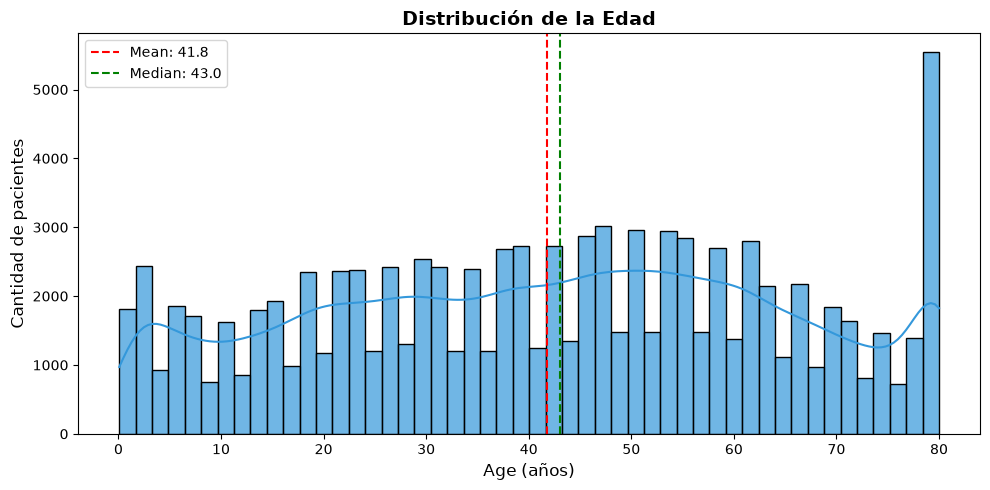

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=diabetes, x='age', bins=50, kde=True, color='#3498db', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('Distribución de la Edad', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (años)', fontsize=12)
ax.set_ylabel('Cantidad de pacientes', fontsize=12)
ax.axvline(diabetes['age'].mean(), color='red', linestyle='--', label=f'Mean: {diabetes["age"].mean():.1f}')
ax.axvline(diabetes['age'].median(), color='green', linestyle='--', label=f'Median: {diabetes["age"].median():.1f}')
ax.legend()
plt.tight_layout()

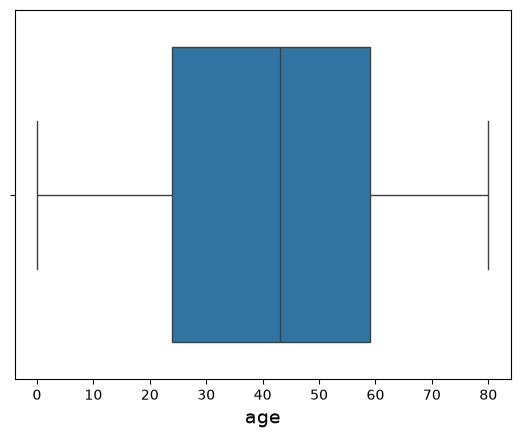

In [18]:
sns.boxplot(x=diabetes["age"])
plt.show()

In [62]:
print(f'Asimetría de la distribución de la edad: {diabetes["age"].skew():.2f}')

Asimetría de la distribución de la edad: -0.06


**Edad:** abarca de 0.08 a 80 años con media ≈ 41.8 y distribución casi uniforme (asimetría ≈ 0): no hay una franja etaria dominante y el boxplot no muestra atípicos. Cerca del 17% son menores de 18 años.

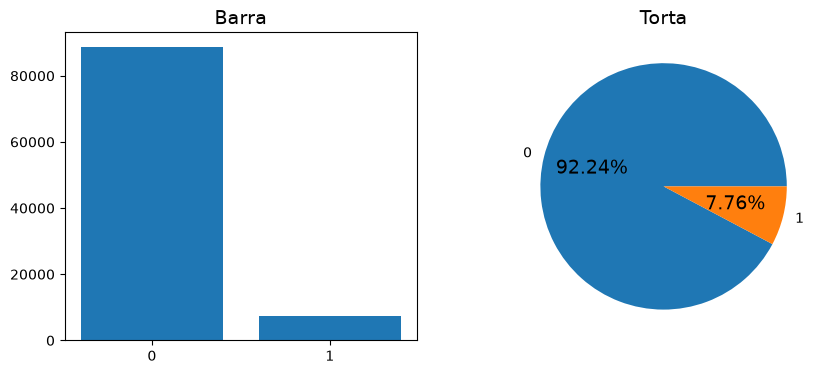

In [25]:
hypertension_counts = diabetes["hypertension"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(hypertension_counts.index.astype(str), hypertension_counts.values)
axes[0].set_title("Barra")

axes[1].pie(x=hypertension_counts.values, labels=hypertension_counts.index, autopct="%.2f%%")
axes[1].set_title("Torta")

plt.show()

**Hipertensión:** variable binaria muy desbalanceada: solo el 7.76% de los registros (7461) presenta hipertensión. Es minoritaria pero clínicamente clave, ya que es un factor de riesgo clásico de diabetes.

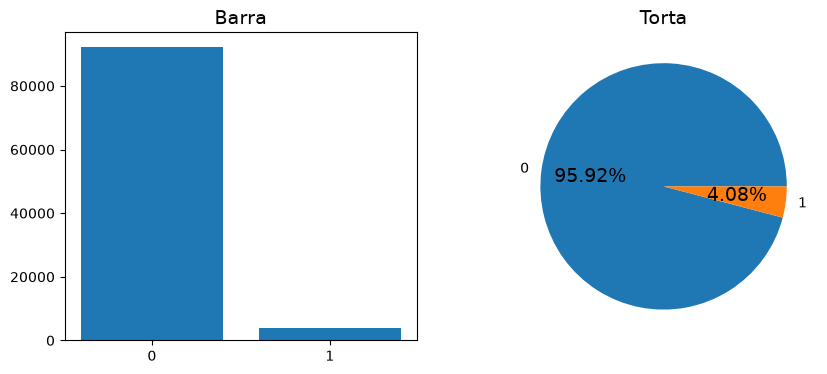

In [26]:
heart_disease_counts = diabetes["heart_disease"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(heart_disease_counts.index.astype(str), heart_disease_counts.values)
axes[0].set_title("Barra")

axes[1].pie(x=heart_disease_counts.values, labels=heart_disease_counts.index, autopct="%.2f%%")
axes[1].set_title("Torta")

plt.show()

**Enfermedad cardíaca:** aún más escasa que la hipertensión: solo 4.08% de positivos (3923 registros). El fuerte desbalance hacia 0 es esperable en población general, pero conviene prestar atención para modelar.

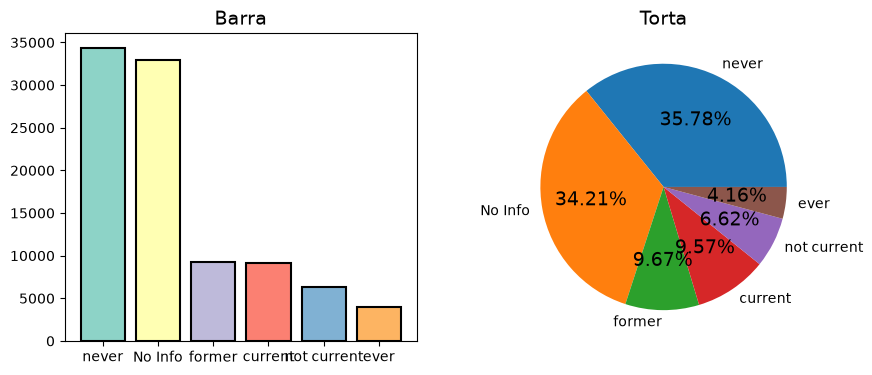

In [32]:
smoking_history_counts = diabetes["smoking_history"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

smoking_labels = smoking_history_counts.index.to_list()
colors = plt.cm.Set3(range(len(smoking_labels)))

axes[0].bar(smoking_labels,smoking_history_counts.values,edgecolor='black', linewidth=1.5, color=colors)
axes[0].set_title("Barra")

axes[1].pie(x=smoking_history_counts.values, labels=smoking_history_counts.index, autopct="%.2f%%")
axes[1].set_title("Torta")

plt.show()

**Historial de tabaquismo:** predominan *never* (35.78%) y *No Info* (34.21%): más de un tercio no declara datos, lo que introduce ruido en esta variable. Los fumadores actuales son ~9.6% y los ex fumadores ~9.7%.

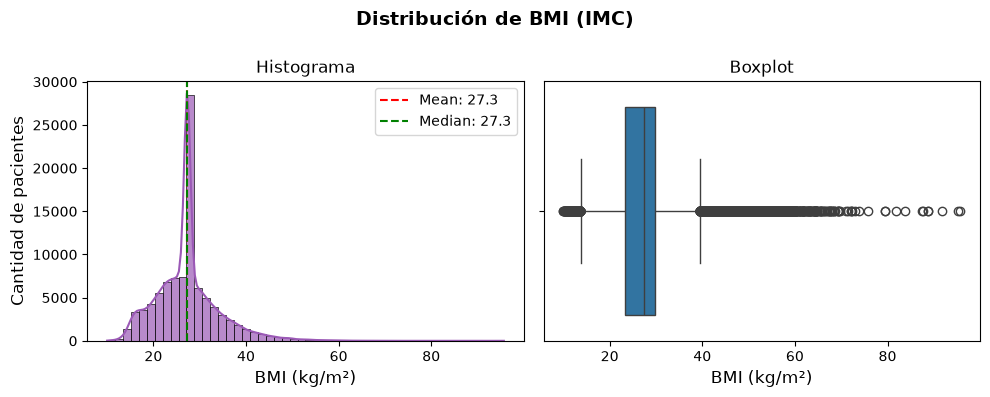

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribución de BMI (IMC)', fontsize=14, fontweight='bold')

sns.histplot(data=diabetes, x='bmi', bins=50, kde=True, color='#9b59b6', edgecolor='black', alpha=0.7, ax=axes[0])
axes[0].set_xlabel('BMI (kg/m²)', fontsize=12)
axes[0].set_ylabel('Cantidad de pacientes', fontsize=12)
axes[0].axvline(diabetes['bmi'].mean(), color='red', linestyle='--', label=f'Mean: {diabetes["bmi"].mean():.1f}')
axes[0].axvline(diabetes['bmi'].median(), color='green', linestyle='--', label=f'Median: {diabetes["bmi"].median():.1f}')
axes[0].legend()
axes[0].set_title("Histograma")

sns.boxplot(x=diabetes["bmi"], ax=axes[1])
axes[1].set_xlabel('BMI (kg/m²)', fontsize=12)
axes[1].set_title("Boxplot")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

**IMC (bmi):** centrado en 27.3 (rango de sobrepeso según OMS) con asimetría marcada a la derecha (skew ≈ 1). La mayoría se concentra entre ~23 y 30, pero hay una cola de valores extremos: el boxplot marca ~5.6% de atípicos, con máximos de hasta 95.7.

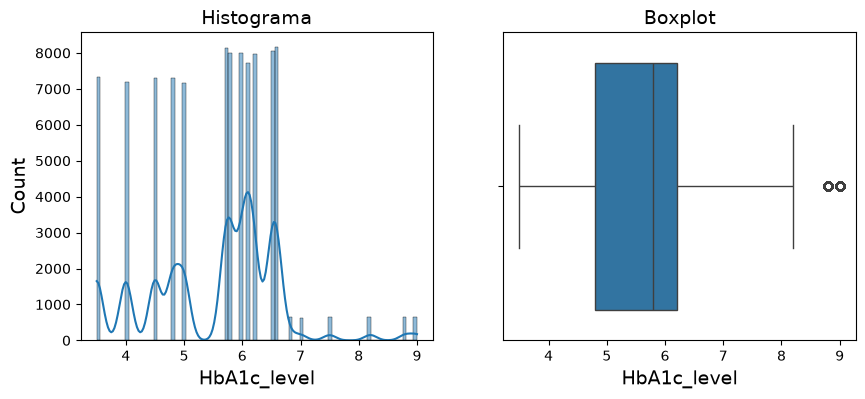

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(x=diabetes["HbA1c_level"], kde=True, ax=axes[0])
axes[0].set_title("Histograma")

sns.boxplot(x=diabetes["HbA1c_level"], ax=axes[1])
axes[1].set_title("Boxplot")

plt.show()

**HbA1c_level:** hemoglobina glucosilada entre 3.5% y 9%, con mediana 5.8% y distribución casi simétrica. Como el umbral diagnóstico de diabetes es 6.5%, la cola derecha corresponde a los registros con valores compatibles con la enfermedad.

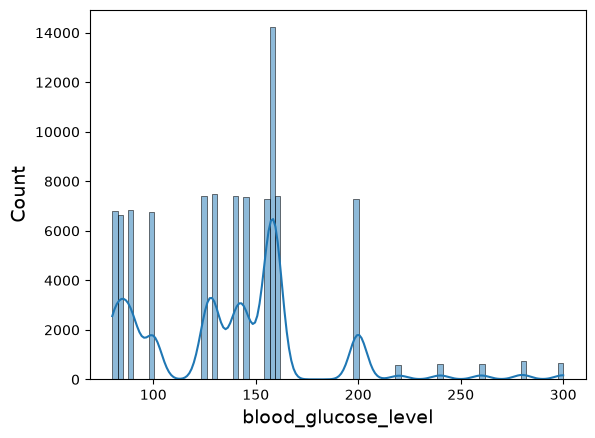

In [33]:
sns.histplot(x=diabetes["blood_glucose_level"], kde=True)
plt.show()

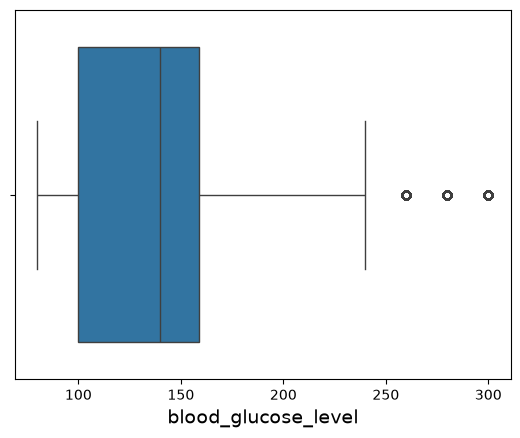

In [34]:
sns.boxplot(x=diabetes["blood_glucose_level"])
plt.show()

**Glucosa en sangre:** mediana de 140 mg/dL (rango 80–300) con asimetría derecha moderada (skew ≈ 0.8). Los atípicos del boxplot corresponden a hiperglucemia (>200 mg/dL), típicamente asociada a diabetes; los picos del histograma reflejan que los niveles se registran en valores discretos.

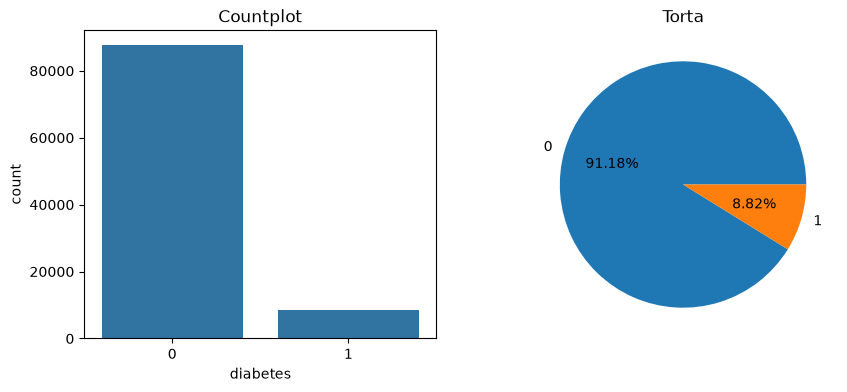

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x=diabetes["diabetes"], ax=axes[0])
axes[0].set_title("Countplot")

diabetes_counts = diabetes["diabetes"].value_counts()
axes[1].pie(x=diabetes_counts.values, labels=diabetes_counts.index, autopct="%.2f%%")
axes[1].set_title("Torta")

plt.show()

In [27]:
diabetes_counts[1]

np.int64(8482)

**Diabetes (variable objetivo):** fuertemente desbalanceada: solo 8.82% de casos positivos (8482 de 96146). Un modelo trivial que predijera siempre 0 acertaría el 91.18%, por lo que conviene evaluar con recall, F1 o PR-AUC y considerar técnicas de balanceo.

Gráficos bi-variables

<Axes: xlabel='diabetes', ylabel='bmi'>

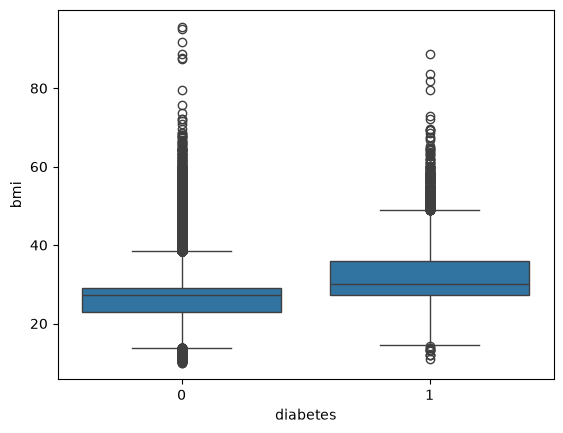

In [29]:
sns.boxplot(x=diabetes['diabetes'],y=diabetes['bmi'])

In [31]:
diabetes.groupby("diabetes")["bmi"].median()

diabetes
0    27.320
1    29.985
Name: bmi, dtype: float64

**IMC según diabetes:** los registros con diabetes (1) muestran una mediana de IMC claramente mayor (~30 vs ~27.3). La distribución del grupo positivo está desplazada hacia arriba y su caja es más amplia, coherente con el sobrepeso/obesidad como factor de riesgo. Hay solapamiento importante entre grupos, por lo que un IMC alto no basta por sí solo para discriminar.

<Axes: xlabel='diabetes', ylabel='age'>

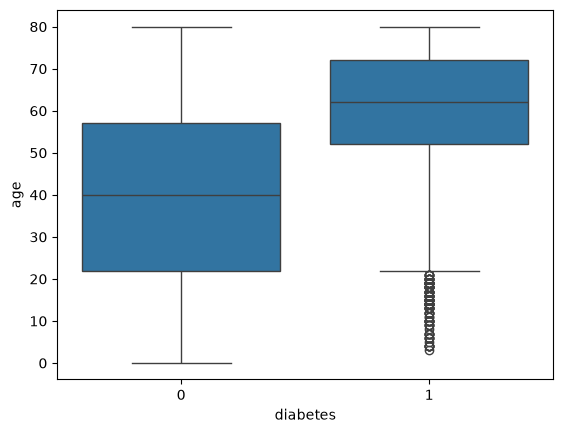

In [30]:
sns.boxplot(x=diabetes['diabetes'],y=diabetes['age'])

**Edad según diabetes:** el efecto es aún más marcado que en el IMC: la mediana de edad pasa de ~40 años en no diabéticos a ~62 años en diabéticos, con cajas casi sin solapamiento en el rango intercuartílico. La edad es uno de los predictores más fuertes del dataset.